In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import os 
os.listdir()

['sign (2).jpeg',
 '[Hindi (auto-generated)] 100 Days of Deep Learning  Course Announcement [DownSub.com] (1).txt',
 '083_SVM_Intuition.pdf',
 'Gemini_Generated_Image_2dgquz2dgquz2dgq.png',
 'dashboard.pdf',
 '[Hindi (auto-generated)] Stochastic Gradient Descent [DownSub.com] (1).txt',
 'googlechrome.dmg',
 '[Hindi (auto-generated)] Transformer Inference  How Inference is done in Transformer  Deep Learning .txt',
 '.Rhistory',
 '[Hindi (auto-generated)] CNN Vs Visual Cortex  The Famous Cat Experiment  History of CNN [DownSub.co.txt',
 '[Hindi (auto-generated)] What is Multi-head Attention in Transformers  Multi-head Attention v Self A.txt',
 'Untitled7.ipynb',
 'Graph Theory_ Spectral Decomposition and Laplacians - Google Gemini.pdf',
 'stochastic notes.pdf',
 'CHERIS SONI SOLID STATE (1).docx',
 'Refactored_Py_DS_ML_Bootcamp-master',
 'Adobe Scan 31 Mar 2026.pdf',
 'classefication_project_plassment (5) (1).ipynb',
 'Advertising.csv',
 'alias_lookup.json',
 '[Hindi (auto-generated)] Ne

In [6]:
df = pd.read_csv(r"regresion ML project.csv")

In [7]:
df.head()

,Record_ID,State,District,Year,Season,Crop_Type,Rainfall_mm,Avg_Temperature_C,Humidity_percent,Soil_Type,Irrigation_Type,Fertilizer_Used_kg,Pesticide_Used_kg,Cultivated_Area_hectares,Yield_ton_per_hectare,Market_Price_per_ton,Farmer_Profit_INR
0,1,Uttarakhand,Dehradun,2014,Kharif,Rice,445.02,23.5,47.3,Black,Sprinkler,344.59,42.22,4471.68,1.83,34361.86,67904
1,2,Uttarakhand,Dehradun,2014,Rabi,Wheat,1410.24,32.3,73.6,Red,Rain-fed,217.81,29.71,1463.13,7.55,52216.79,106010
2,3,Uttarakhand,Dehradun,2014,Kharif,Maize,787.56,33.3,40.6,Laterite,Canal,201.97,24.74,1785.38,3.13,14302.87,70380
3,4,Uttarakhand,Dehradun,2014,Kharif,Cotton,1892.93,30.4,82.4,Alluvial,Tube Well,280.94,43.75,324.54,2.86,27337.56,8166
4,5,Uttarakhand,Dehradun,2014,Zaid,Cotton,1216.14,34.7,43.9,Black,Drip,192.11,41.86,3538.92,6.19,15784.33,314345


In [8]:
df.shape

(7920, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Record_ID                 7920 non-null   int64  
 1   State                     7920 non-null   object 
 2   District                  7920 non-null   object 
 3   Year                      7920 non-null   int64  
 4   Season                    7920 non-null   object 
 5   Crop_Type                 7920 non-null   object 
 6   Rainfall_mm               7920 non-null   float64
 7   Avg_Temperature_C         7920 non-null   float64
 8   Humidity_percent          7920 non-null   float64
 9   Soil_Type                 7920 non-null   object 
 10  Irrigation_Type           7920 non-null   object 
 11  Fertilizer_Used_kg        7920 non-null   float64
 12  Pesticide_Used_kg         7920 non-null   float64
 13  Cultivated_Area_hectares  7920 non-null   float64
 14  Yield_to

In [10]:
df.describe()

,Record_ID,Year,Rainfall_mm,Avg_Temperature_C,Humidity_percent,Fertilizer_Used_kg,Pesticide_Used_kg,Cultivated_Area_hectares,Yield_ton_per_hectare,Market_Price_per_ton,Farmer_Profit_INR
count,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000
mean,3960.500000,2019.000000,1303.157420,28.070985,62.466869,250.312962,32.569508,2563.768706,4.832213,38279.748221,160679.954672
std,2286.451399,3.162477,516.667333,5.806386,15.817427,114.850492,15.916997,1414.030920,2.127995,15273.022319,126720.323375
min,1.000000,2014.000000,400.800000,18.000000,35.000000,50.170000,5.000000,100.650000,1.200000,12014.350000,1495.000000
25%,1980.750000,2016.000000,855.280000,23.000000,49.000000,149.957500,18.650000,1331.842500,2.950000,25045.967500,60727.500000
50%,3960.500000,2019.000000,1305.420000,28.100000,62.700000,251.350000,32.860000,2567.445000,4.850000,38261.045000,129250.500000
75%,5940.250000,2022.000000,1752.057500,33.200000,76.000000,350.692500,46.302500,3796.015000,6.680000,51779.057500,228904.750000
max,7920.000000,2024.000000,2199.580000,38.000000,90.000000,449.900000,59.980000,4999.300000,8.500000,64998.760000,721789.000000


In [11]:
df.describe(include="object")

,State,District,Season,Crop_Type,Soil_Type,Irrigation_Type
count,7920,7920,7920,7920,7920,7920
unique,8,40,3,8,5,5
top,Uttarakhand,Dehradun,Kharif,Barley,Black,Tube Well
freq,990,198,2673,1040,1621,1636


In [12]:
df.isnull().sum()

Record_ID                   0
State                       0
District                    0
Year                        0
Season                      0
Crop_Type                   0
Rainfall_mm                 0
Avg_Temperature_C           0
Humidity_percent            0
Soil_Type                   0
Irrigation_Type             0
Fertilizer_Used_kg          0
Pesticide_Used_kg           0
Cultivated_Area_hectares    0
Yield_ton_per_hectare       0
Market_Price_per_ton        0
Farmer_Profit_INR           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop(columns="Record_ID", inplace=True)

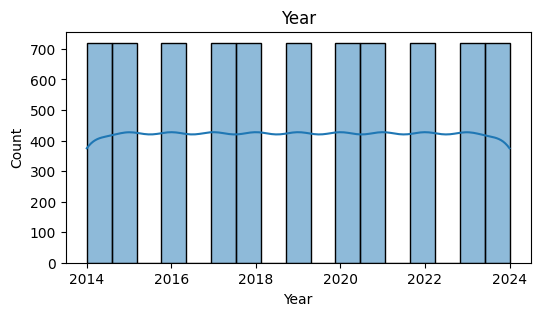

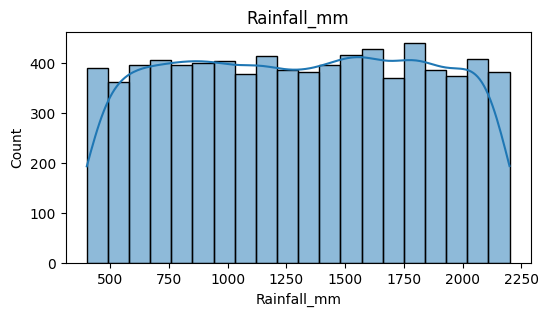

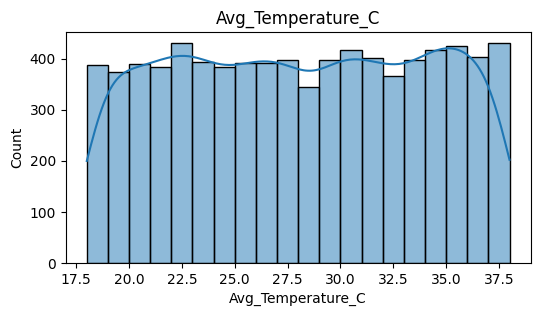

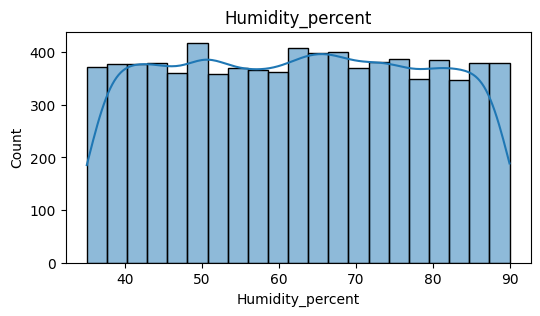

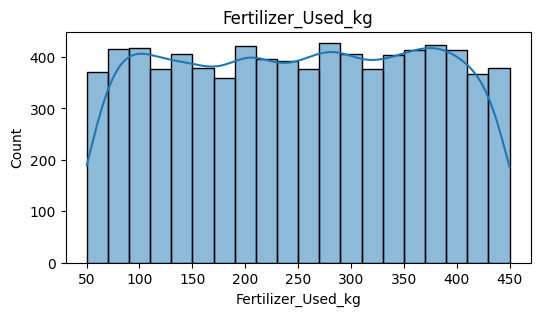

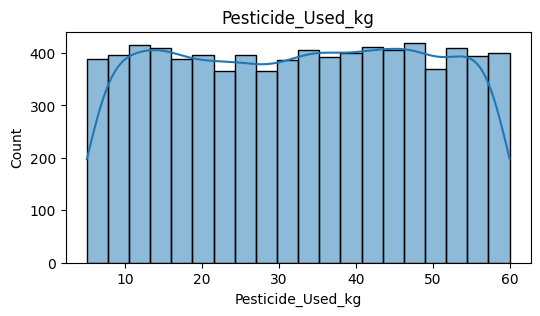

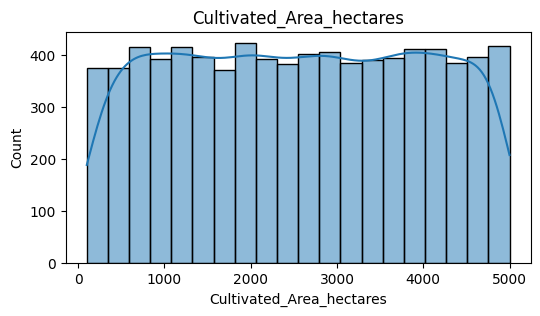

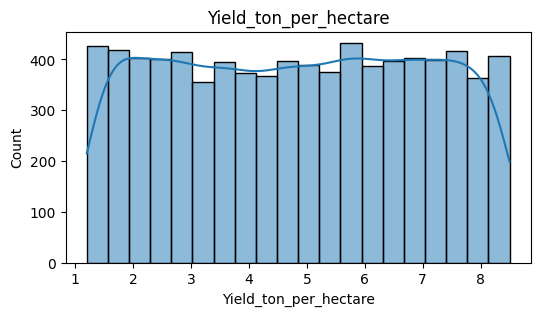

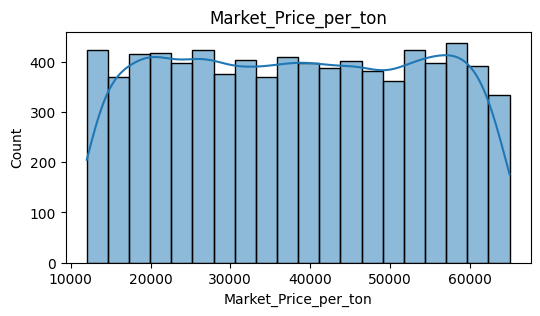

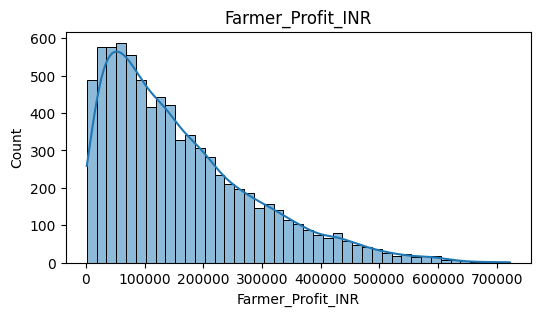

In [15]:
num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

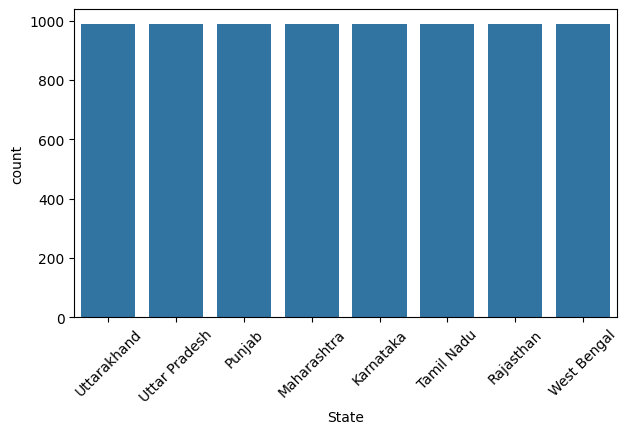

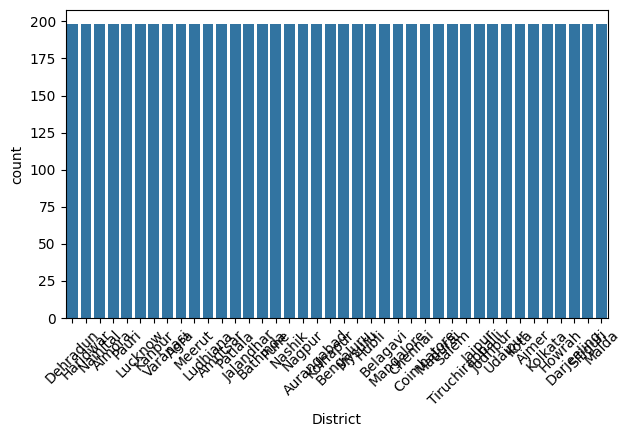

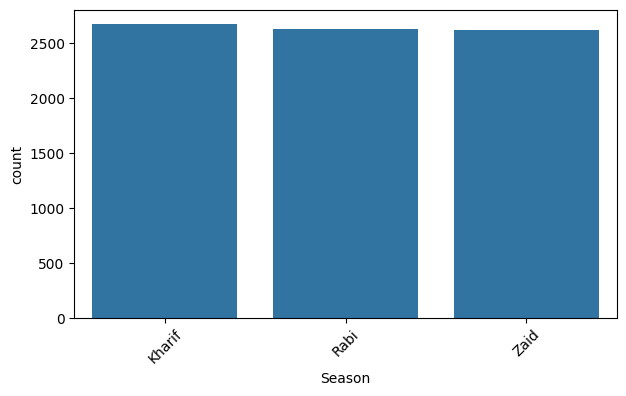

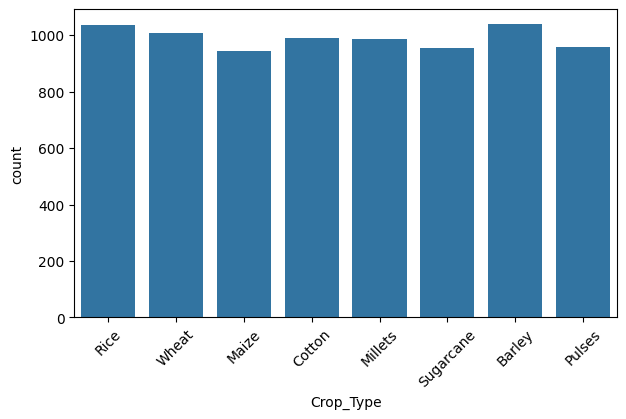

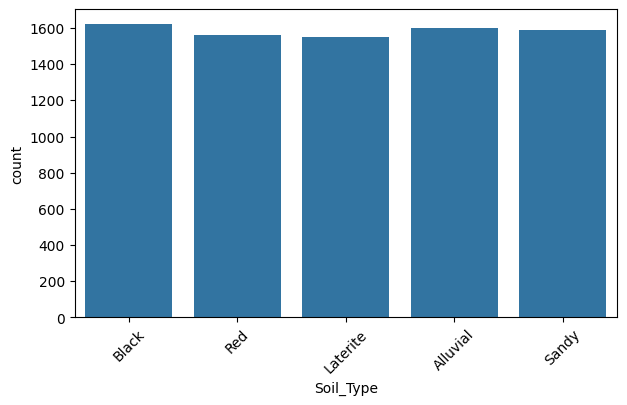

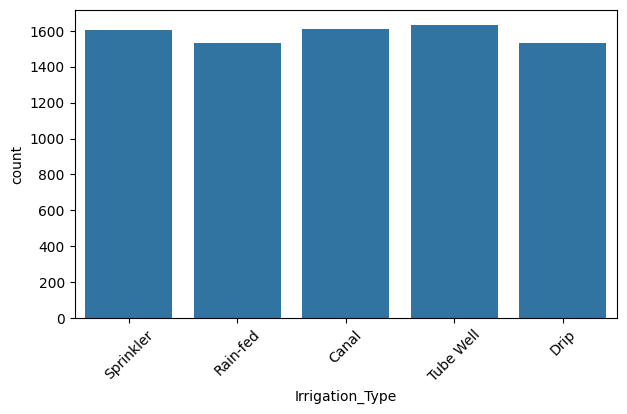

In [16]:
cat_cols=df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)
    plt.show()

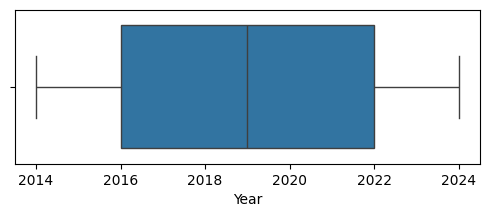

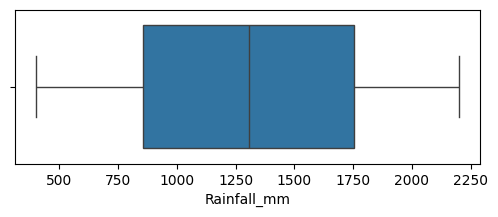

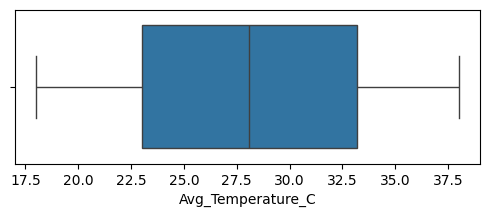

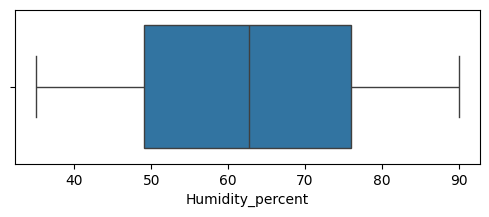

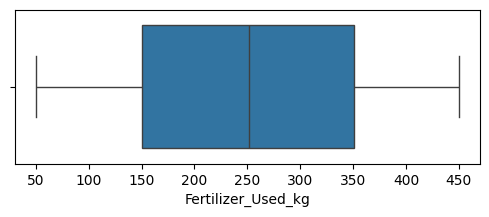

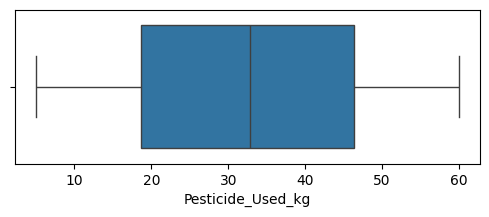

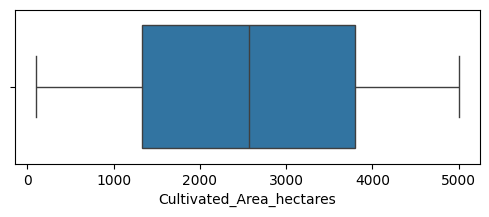

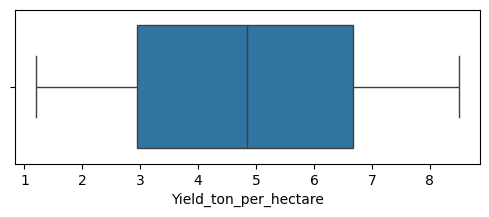

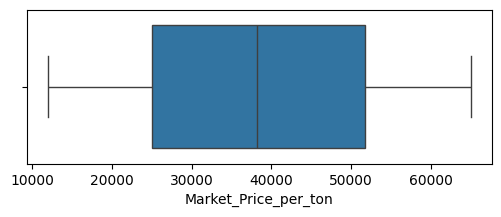

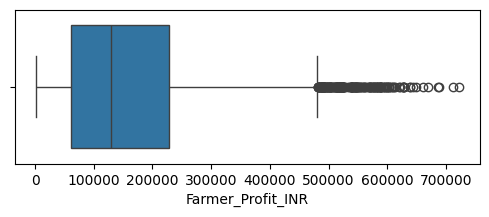

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.show()

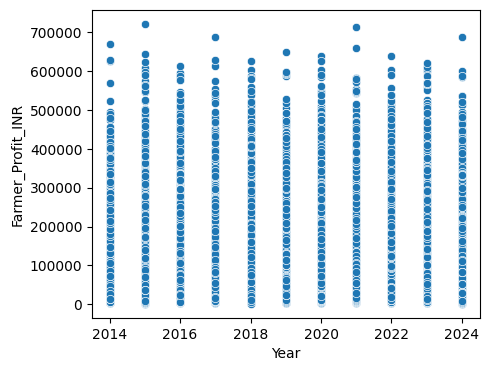

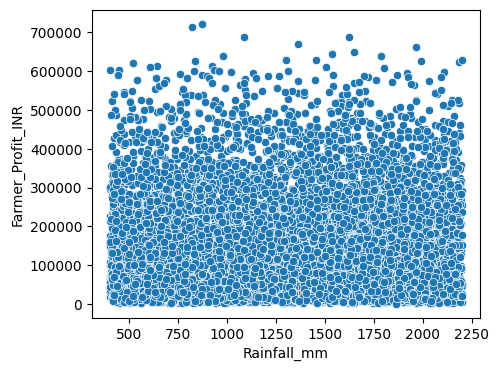

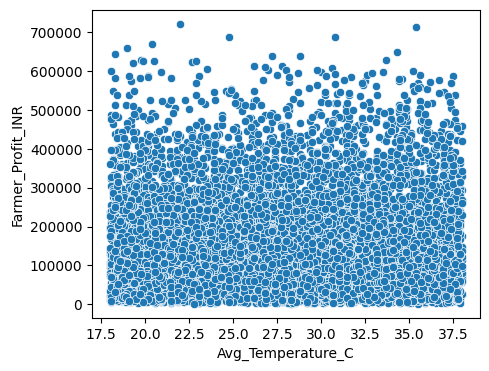

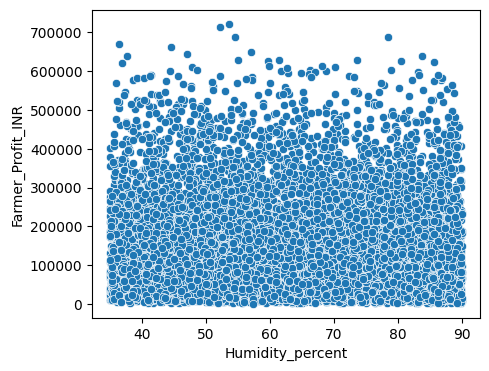

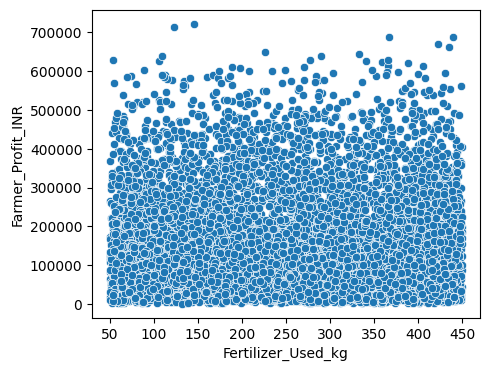

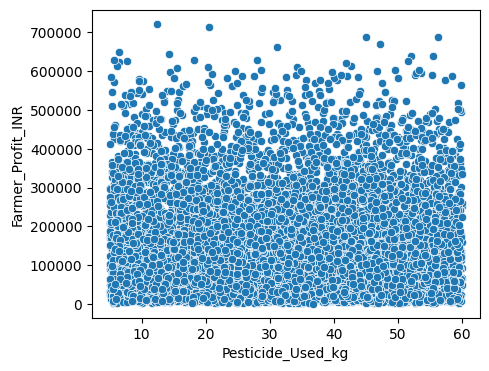

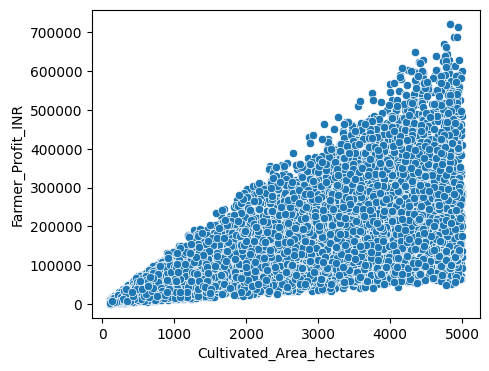

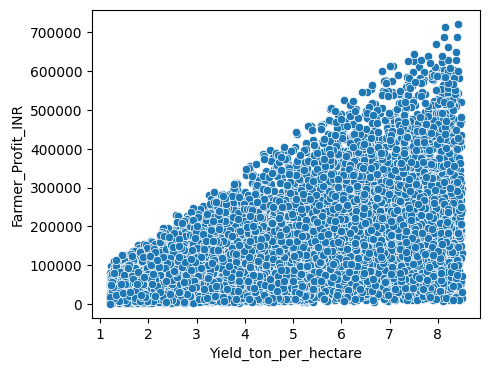

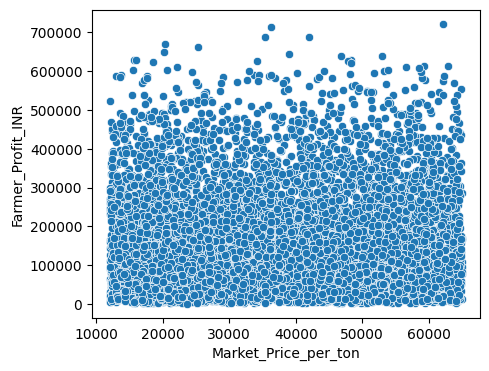

In [18]:
for col in num_cols.drop("Farmer_Profit_INR"):
    plt.figure(figsize=(5,4))
    sns.scatterplot(data=df,x=col,y="Farmer_Profit_INR")
    plt.show()

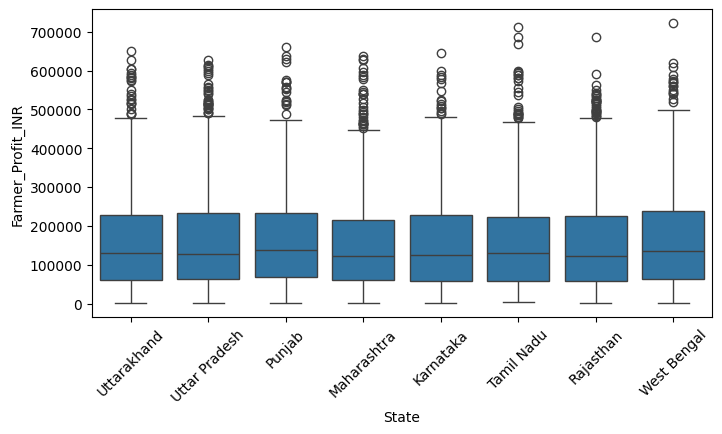

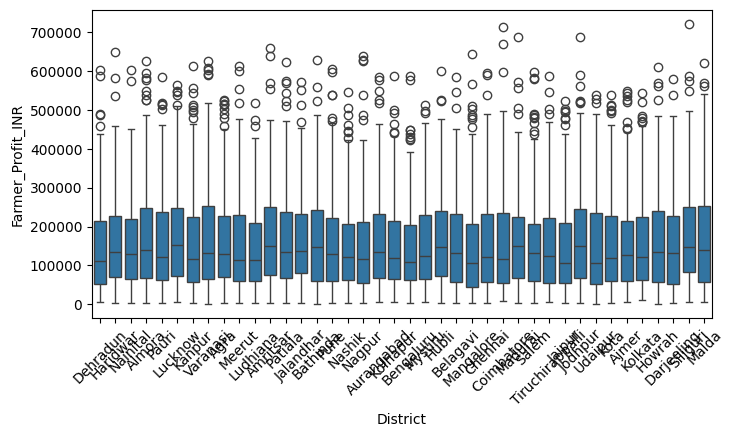

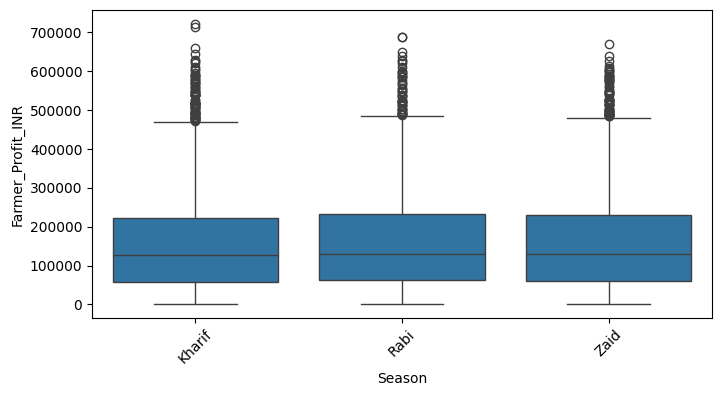

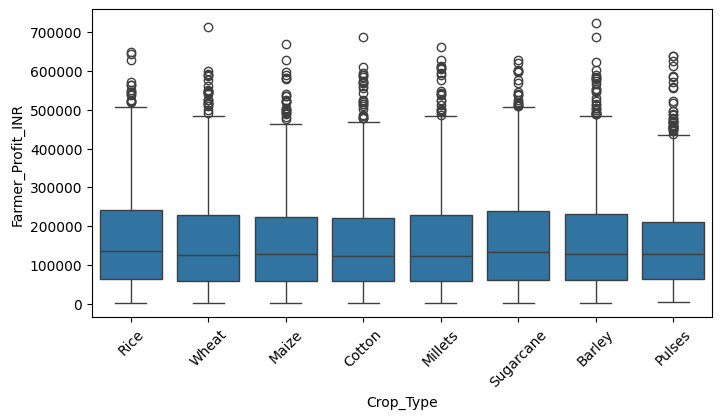

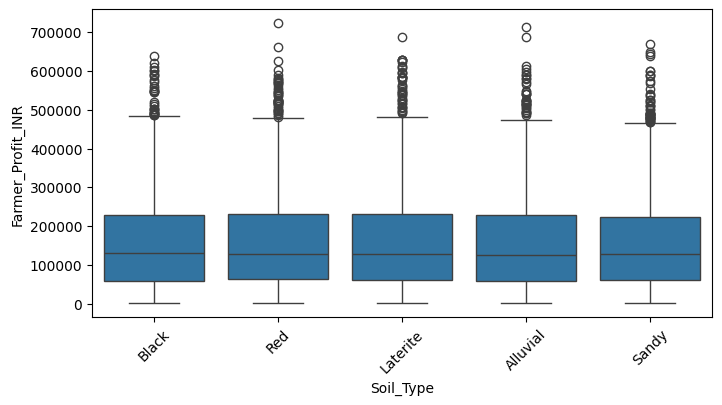

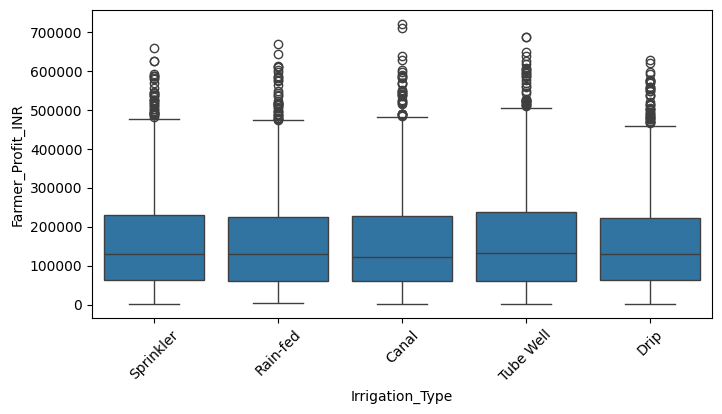

In [19]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df,x=col,y="Farmer_Profit_INR")
    plt.xticks(rotation=45)
    plt.show()

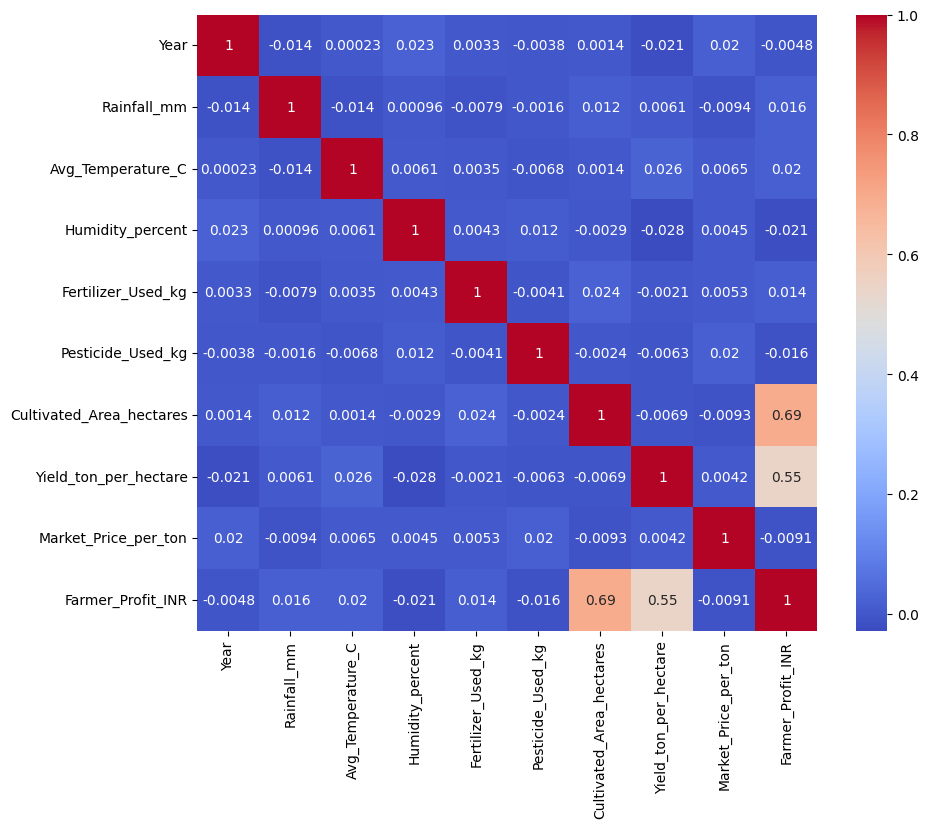

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [21]:
df["Fertilizer_per_Hectare"] = (
    df["Fertilizer_Used_kg"] /
    df["Cultivated_Area_hectares"]
)

In [22]:
df["Pesticide_per_Hectare"] = (
    df["Pesticide_Used_kg"] /
    df["Cultivated_Area_hectares"]
)

In [23]:
df["Rain_Temp_Index"] = (
    df["Rainfall_mm"] *
    df["Avg_Temperature_C"]
)

In [24]:
X=df.drop(columns=["Farmer_Profit_INR","Pesticide_Used_kg","Rainfall_mm"],axis=1)

y=df["Farmer_Profit_INR"]

In [25]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
num_features=X_train.select_dtypes(include=np.number).columns

cat_features=X_train.select_dtypes(include="object").columns

In [27]:
numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [28]:
categorical_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [31]:
preprocessor=ColumnTransformer([
    ("num",numeric_transformer,num_features),
    ("cat",categorical_transformer,cat_features)
])

In [32]:
lr_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])


In [33]:
lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [34]:
df.head()

,State,District,Year,Season,Crop_Type,Rainfall_mm,Avg_Temperature_C,Humidity_percent,Soil_Type,Irrigation_Type,Fertilizer_Used_kg,Pesticide_Used_kg,Cultivated_Area_hectares,Yield_ton_per_hectare,Market_Price_per_ton,Farmer_Profit_INR,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rain_Temp_Index
0,Uttarakhand,Dehradun,2014,Kharif,Rice,445.02,23.5,47.3,Black,Sprinkler,344.59,42.22,4471.68,1.83,34361.86,67904,0.077061,0.009442,10457.970
1,Uttarakhand,Dehradun,2014,Rabi,Wheat,1410.24,32.3,73.6,Red,Rain-fed,217.81,29.71,1463.13,7.55,52216.79,106010,0.148866,0.020306,45550.752
2,Uttarakhand,Dehradun,2014,Kharif,Maize,787.56,33.3,40.6,Laterite,Canal,201.97,24.74,1785.38,3.13,14302.87,70380,0.113124,0.013857,26225.748
3,Uttarakhand,Dehradun,2014,Kharif,Cotton,1892.93,30.4,82.4,Alluvial,Tube Well,280.94,43.75,324.54,2.86,27337.56,8166,0.865656,0.134806,57545.072
4,Uttarakhand,Dehradun,2014,Zaid,Cotton,1216.14,34.7,43.9,Black,Drip,192.11,41.86,3538.92,6.19,15784.33,314345,0.054285,0.011828,42200.058


In [35]:
train_pred=lr_pipeline.predict(X_train)

test_pred=lr_pipeline.predict(X_test)

In [36]:
def evaluate(y_true,y_pred):

    print("R2 :",r2_score(y_true,y_pred))

    print("MAE:",mean_absolute_error(y_true,y_pred))

    print("RMSE:",np.sqrt(mean_squared_error(y_true,y_pred)))

In [37]:
evaluate(y_train,train_pred)

evaluate(y_test,test_pred)

R2 : 0.7851122108675371
MAE: 45846.312464133924
RMSE: 58487.59384053349
R2 : 0.7846874249474631
MAE: 46071.733419797674
RMSE: 59786.71835519995


In [38]:
scores=cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)

print(scores.mean())

[0.77006927 0.78495626 0.79153397 0.78199691 0.77759201]
0.7812296839137398


In [39]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [40]:
ridge_train_pred = ridge_pipeline.predict(X_train)
ridge_test_pred = ridge_pipeline.predict(X_test)

In [41]:
print("Ridge Regression")

print("\nTrain Performance")
evaluate(y_train, ridge_train_pred)

print("\nTest Performance")
evaluate(y_test, ridge_test_pred)

Ridge Regression

Train Performance
R2 : 0.7851119701012449
MAE: 45843.22191569924
RMSE: 58487.62660609273

Test Performance
R2 : 0.7846833131649065
MAE: 46067.62581043289
RMSE: 59787.28922016676


In [42]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.640e+11, tolerance: 1.009e+10
  model = cd_fast.sparse_enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [43]:
lasso_train_pred = lasso_pipeline.predict(X_train)
lasso_test_pred = lasso_pipeline.predict(X_test)

In [44]:
print("Lasso Regression")

print("\nTrain Performance")
evaluate(y_train, lasso_train_pred)

print("\nTest Performance")
evaluate(y_test, lasso_test_pred)

Lasso Regression

Train Performance
R2 : 0.7851122098713543
MAE: 45846.25931421699
RMSE: 58487.593976102704

Test Performance
R2 : 0.7846874641471088
MAE: 46071.61073020464
RMSE: 59786.71291283719


In [45]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

In [ ]:
print("Random Forest")

print("\nTrain Performance")
evaluate(y_train, rf_train_pred)

print("\nTest Performance")
evaluate(y_test, rf_test_pred)